Using device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 138MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 35.6MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 122MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.36MB/s]


Training samples: 60000
Test samples: 10000
Number of classes: 10


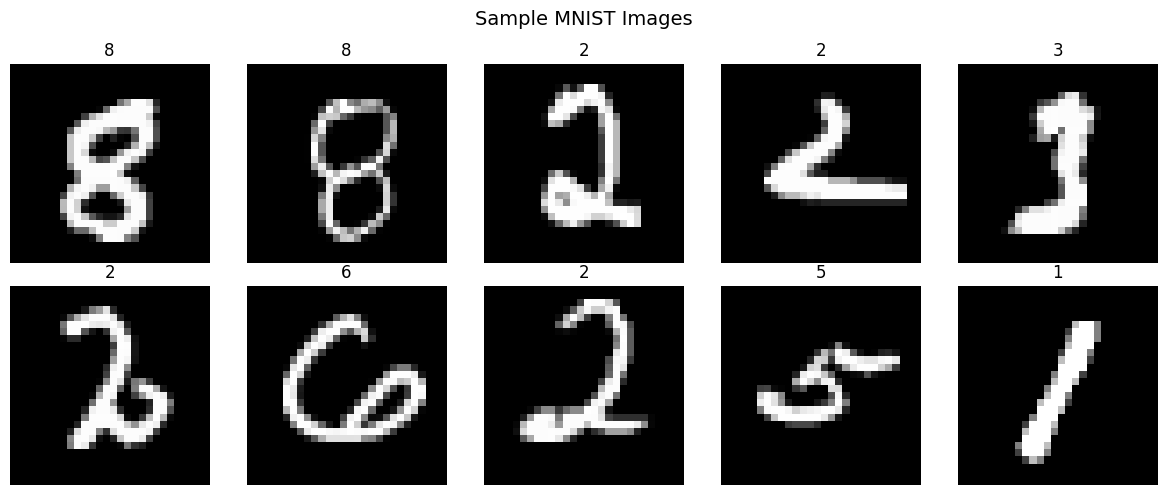

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)
classes = [str(i) for i in range(10)]
print(f'Training samples: {len(trainset)}')
print(f'Test samples: {len(testset)}')
print(f'Number of classes: {len(classes)}')
dataiter = iter(trainloader)
images, labels = next(dataiter)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img = images[i].squeeze().numpy()
    ax.imshow(img, cmap='gray')
    ax.set_title(classes[labels[i]])
    ax.axis('off')
plt.suptitle('Sample MNIST Images', fontsize=14)
plt.tight_layout()
plt.show()

In [2]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, 10)
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(-1, 128 * 3 * 3)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x
model = SimpleCNN().to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=1152, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

Total parameters: 390,410


In [3]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print('Loss: CrossEntropyLoss')
print('Optimizer: Adam (lr=0.001)')
num_epochs = 10
train_losses = []
train_accuracies = []
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / len(trainloader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    print(f'Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')
print('\nTraining complete!')

Loss: CrossEntropyLoss
Optimizer: Adam (lr=0.001)
Epoch [1/10] - Loss: 0.1513, Accuracy: 95.16%
Epoch [2/10] - Loss: 0.0446, Accuracy: 98.63%
Epoch [3/10] - Loss: 0.0351, Accuracy: 98.91%
Epoch [4/10] - Loss: 0.0250, Accuracy: 99.23%
Epoch [5/10] - Loss: 0.0206, Accuracy: 99.38%
Epoch [6/10] - Loss: 0.0190, Accuracy: 99.44%
Epoch [7/10] - Loss: 0.0147, Accuracy: 99.55%
Epoch [8/10] - Loss: 0.0144, Accuracy: 99.54%
Epoch [9/10] - Loss: 0.0125, Accuracy: 99.58%
Epoch [10/10] - Loss: 0.0121, Accuracy: 99.61%

Training complete!


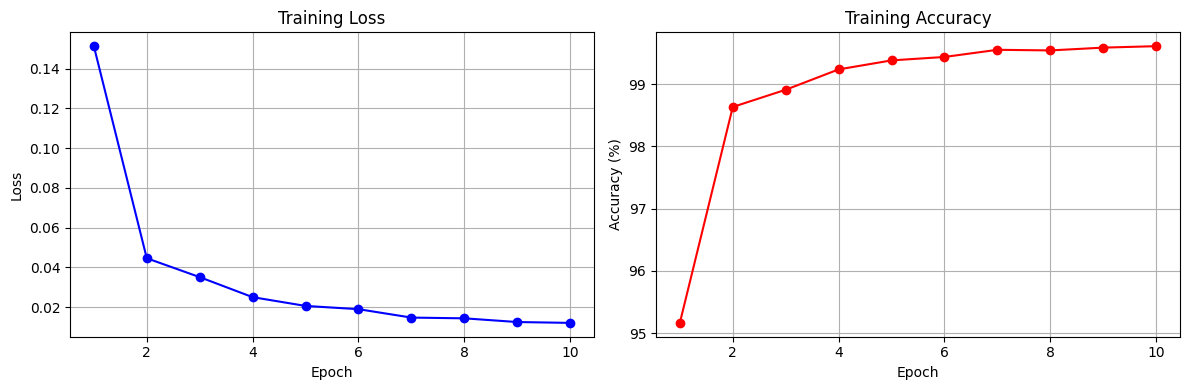

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(range(1, num_epochs+1), train_losses, 'b-o')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)
ax2.plot(range(1, num_epochs+1), train_accuracies, 'r-o')
ax2.set_title('Training Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True)
plt.tight_layout()
plt.show()

Test Accuracy: 99.13%
Per-class accuracy:
------------------------------
 0: 99.9%
 1: 99.7%
 2: 99.6%
 3: 99.8%
 4: 99.8%
 5: 99.2%
 6: 99.1%
 7: 98.3%
 8: 98.0%
 9: 97.7%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      1.00      0.99      1135
           2       0.98      1.00      0.99      1032
           3       0.98      1.00      0.99      1010
           4       0.98      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       1.00      0.98      0.99      1028
           8       1.00      0.98      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



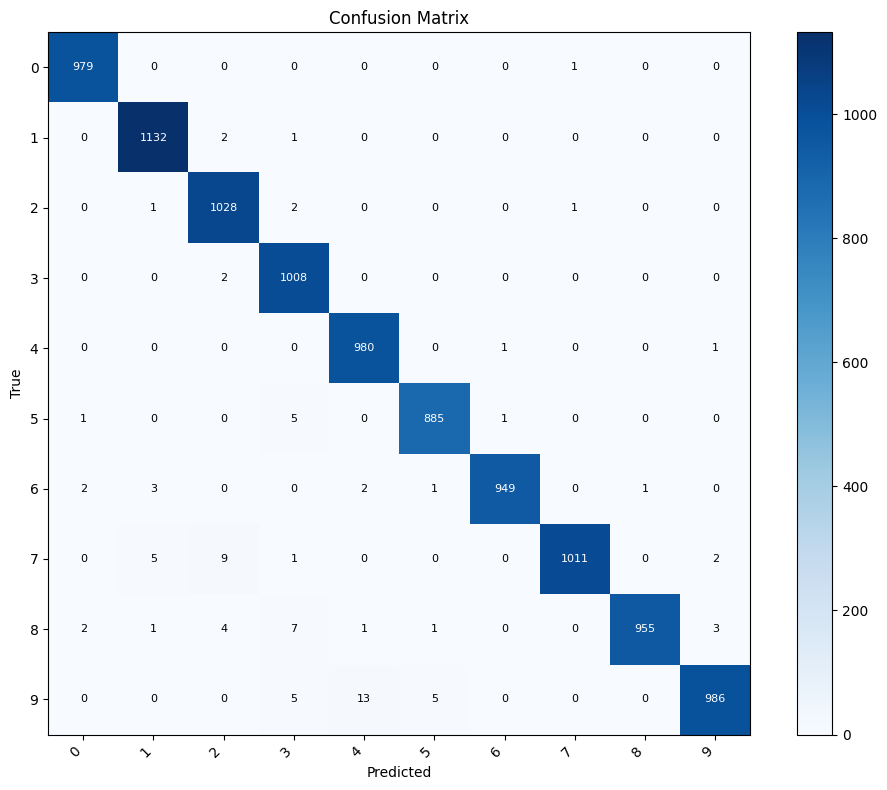

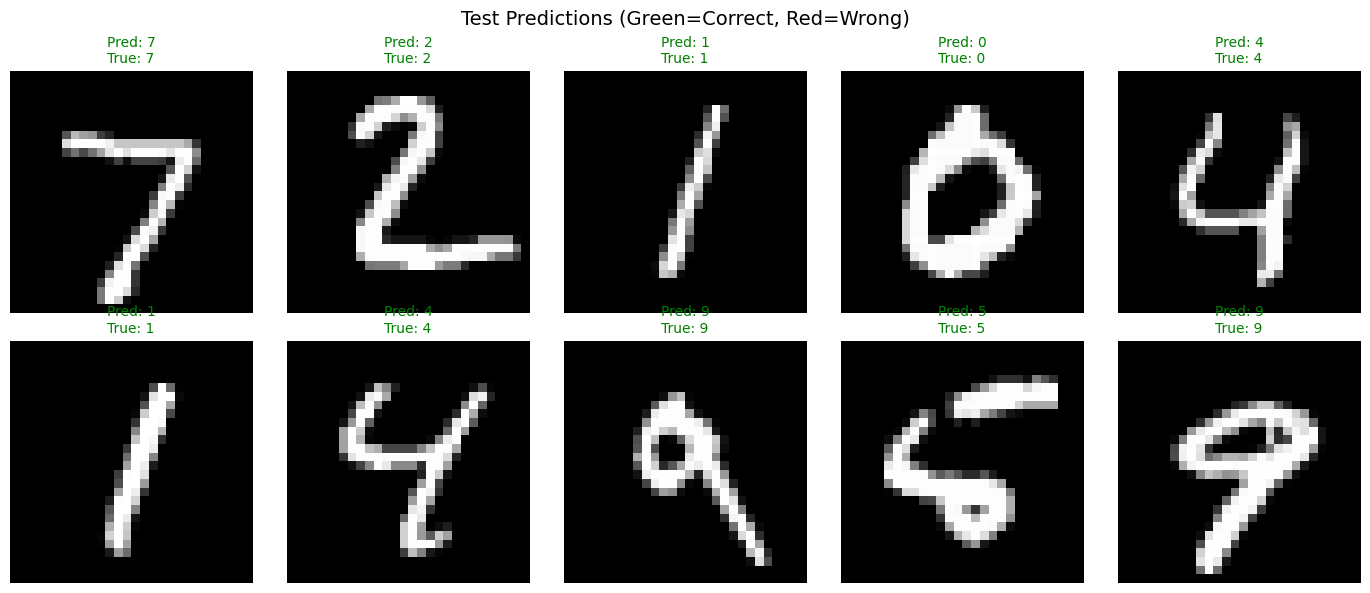

In [5]:
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
test_accuracy = 100 * correct / total
print(f'Test Accuracy: {test_accuracy:.2f}%')
class_correct = [0] * 10
class_total = [0] * 10
for pred, label in zip(all_preds, all_labels):
    class_total[label] += 1
    if pred == label:
        class_correct[label] += 1
print('Per-class accuracy:')
print('-' * 30)
for i in range(10):
    acc = 100 * class_correct[i] / class_total[i]
    print(f'{classes[i]:>2s}: {acc:.1f}%')
print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=classes))
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.set_title('Confusion Matrix')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.set_yticklabels(classes)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
for i in range(10):
    for j in range(10):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=8)
plt.tight_layout()
plt.show()
dataiter = iter(testloader)
images, labels = next(dataiter)
model.eval()
with torch.no_grad():
    outputs = model(images.to(device))
    _, preds = torch.max(outputs, 1)
    preds = preds.cpu()
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img = images[i].squeeze().numpy()
    ax.imshow(img, cmap='gray')
    color = 'green' if preds[i] == labels[i] else 'red'
    ax.set_title(f'Pred: {classes[preds[i]]}\nTrue: {classes[labels[i]]}', color=color, fontsize=10)
    ax.axis('off')
plt.suptitle('Test Predictions (Green=Correct, Red=Wrong)', fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
torch.save(model.state_dict(), 'mnist_cnn_model.pth')
print('Model saved to mnist_cnn_model.pth')

Model saved to mnist_cnn_model.pth
